In [2]:
from pathlib import Path
import re
from typing import Iterable

import os
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path(os.path.abspath('')).resolve().parents[2]
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import nvitk as nv
import numpy as np
# from nvitk.core import setup
# setup(globals())

from nvitk.core.logger import Logger
log = Logger()

In [3]:
def load_ctpet_fat_suv_measurements(
    original_results_root: str | Path,
    ureter_results_root: str | Path,
    *,
    id_col: str = "pesa_id",
    batch_regex: str | None = r"^\d{6}_Week\d+$",
    fat_prefixes: tuple[str, ...] = ("GRASA_V", "GRASA_SC"),
    suv_suffixes: tuple[str, ...] = ("SUVMAX", "SUVmean", "SUV95p"),
) -> pd.DataFrame:
    """
    Load CT-PET stage-3 summary rows from two result roots and merge them.

    Expected file pattern per batch:
      <root>/<batch>/res_measure_suv/<batch>_SummaryCodebook.xlsx

    Returns columns:
      [batch, pesa_id, <fat_suv_cols>_orig, <fat_suv_cols>_ureter]
    """
    original_results_root = Path(original_results_root)
    ureter_results_root = Path(ureter_results_root)

    def _collect(root: Path, tag: str) -> pd.DataFrame:
        frames = []
        for xlsx in root.glob("*/res_measure_suv/*_SummaryCodebook.xlsx"):
            batch = xlsx.parent.parent.name  # <root>/<batch>/res_measure_suv/...
            if batch_regex is not None:
                import re
                if not re.match(batch_regex, batch):
                    continue

            df = pd.read_excel(xlsx)
            if id_col not in df.columns:
                continue

            target_cols = [
                c for c in df.columns
                if any(c.startswith(f"{p}_") for p in fat_prefixes)
                and any(c.endswith(s) for s in suv_suffixes)
            ]

            keep = [id_col] + target_cols
            tmp = df[keep].copy()
            tmp["batch"] = batch
            tmp = tmp.rename(columns={c: f"{c}_{tag}" for c in target_cols})
            frames.append(tmp)

        if not frames:
            return pd.DataFrame(columns=["batch", id_col])

        out = pd.concat(frames, ignore_index=True)
        out = out.drop_duplicates(subset=["batch", id_col], keep="last")
        return out

    df_orig = _collect(original_results_root, "orig")
    df_ureter = _collect(ureter_results_root, "ureter")

    merged = pd.merge(
        df_orig,
        df_ureter,
        on=["batch", id_col],
        how="inner",
        validate="one_to_one",
    ).sort_values(["batch", id_col]).reset_index(drop=True)

    return merged


def plot_ctpet_fat_suv_correlations(
    df_merged: pd.DataFrame,
    *,
    cols: Iterable[str] | None = None,
    figsize_per_plot: tuple[float, float] = (4.8, 4.0),
) -> None:
    """
    Scatter plots for matched fat SUV columns:
      <base>_orig vs <base>_ureter
    """
    if cols is None:
        orig_bases = {c[:-5] for c in df_merged.columns if c.endswith("_orig")}
        ureter_bases = {c[:-7] for c in df_merged.columns if c.endswith("_ureter")}
        cols = sorted(orig_bases & ureter_bases)

    cols = list(cols)
    if not cols:
        raise ValueError("No matched *_orig / *_ureter columns to plot.")

    n = len(cols)
    ncols = min(3, n)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize_per_plot[0] * ncols, figsize_per_plot[1] * nrows),
        squeeze=False,
    )

    for i, base in enumerate(cols):
        ax = axes[i // ncols][i % ncols]

        x = pd.to_numeric(df_merged[f"{base}_orig"], errors="coerce")
        y = pd.to_numeric(df_merged[f"{base}_ureter"], errors="coerce")
        m = x.notna() & y.notna()
        x, y = x[m], y[m]

        if len(x) == 0:
            ax.set_title(f"{base}\n(no paired data)")
            ax.axis("off")
            continue

        r = x.corr(y, method="pearson")
        ax.scatter(x, y, alpha=0.7, s=20)

        lo = float(np.nanmin([x.min(), y.min()]))
        hi = float(np.nanmax([x.max(), y.max()]))
        ax.plot([lo, hi], [lo, hi], "--", linewidth=1)

        ax.set_title(f"{base}\nr={r:.3f}  n={len(x)}")
        ax.set_xlabel("Original RESULTS")
        ax.set_ylabel("RESULTS_URETER")

    for j in range(n, nrows * ncols):
        axes[j // ncols][j % ncols].axis("off")

    fig.tight_layout()
    plt.show()

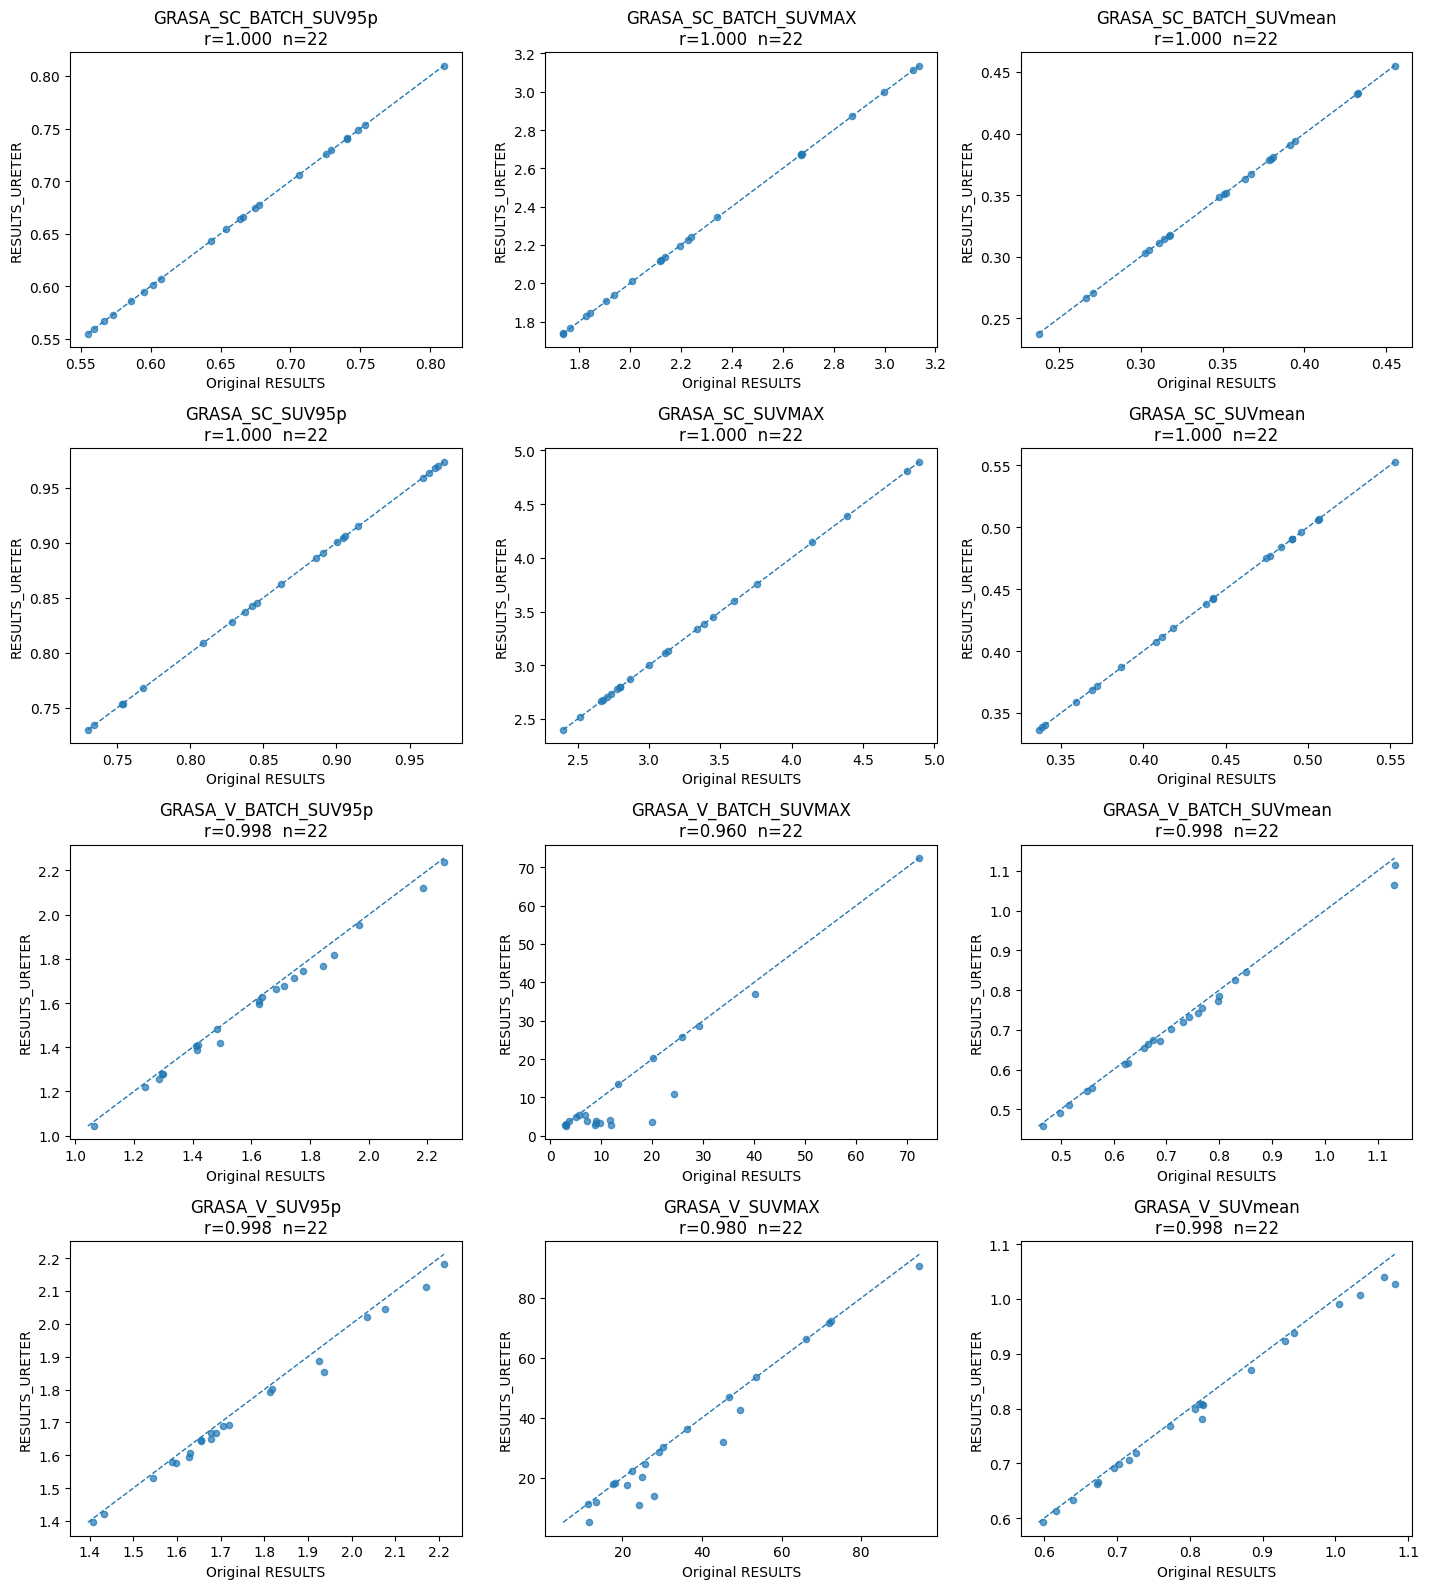

In [4]:
df_cmp = load_ctpet_fat_suv_measurements(
    "/data3/BIOIT_IMAGE/PESA_Fat/DATA/Visit-5-DIXON_PET-CT/RESULTS/",
    "/data3/BIOIT_IMAGE/PESA_Fat/DATA/Visit-5-DIXON_PET-CT/RESULTS_URETER/",
)

plot_ctpet_fat_suv_correlations(df_cmp)